In [1]:
# !pip install ncmcm

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.cognitive_graphs.cognitive_graphs import behavioral_state_diagram
from sklearn.ensemble import RandomForestClassifier
from ncmcm.cognitive_graphs.cognitive_graphs import cluster_neural_activity
from ncmcm.statistical_testing.markov import *
from IPython.display import HTML
import os

In [3]:
os.getcwd()
os.chdir('..')

## Load Data (excluding behavioural neurons)

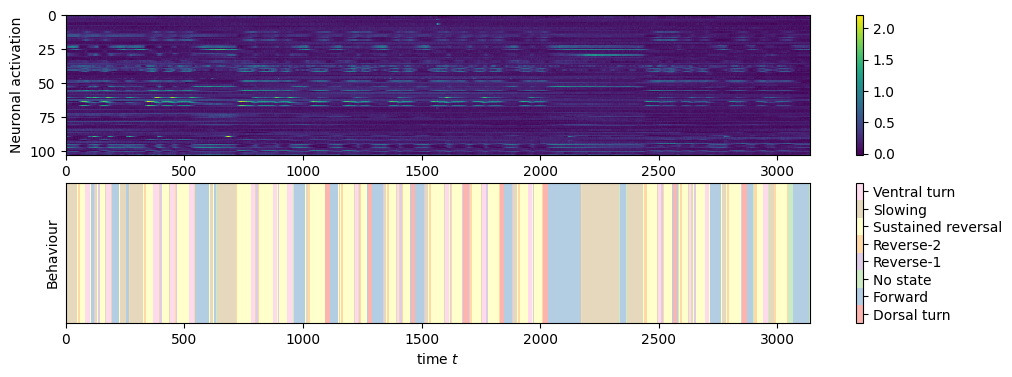

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [4]:
worm_num = 0
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = 'datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces
b = data.behaviour
behaviors = list(data.behaviour_names.values())

plotting_neuronal_behavioural(x.T, b, b_names=data.behaviour_names)

## Cognitive state sequence by clustering behavioral probability trajectories (BPT)

In [5]:
p, _ = markov_property_test(b, simulations=250)
p

0.03200000000000003

We got a p-value of 0.032 (< 0.05) which indicates that the sequence of behaviors does not seem to follow a Markov process of 1st order.

This next method `cluster_neural_activity` allows for a lot of customizability, with only the first 3 parameters being required
For the model parameter each classifier with the methods: predict, predict_proba and fit works fine

Accuracy for full training data: 0.9993624481989162
Testing markovianity for 3 clusters - repetition 1
Testing markovianity for 3 clusters - repetition 2
Testing markovianity for 3 clusters - repetition 3
Testing markovianity for 3 clusters - repetition 4
Testing markovianity for 3 clusters - repetition 5
Testing markovianity for 3 clusters - repetition 6
Testing markovianity for 3 clusters - repetition 7
Testing markovianity for 3 clusters - repetition 8
Testing markovianity for 3 clusters - repetition 9
Testing markovianity for 3 clusters - repetition 10
(10, 3)


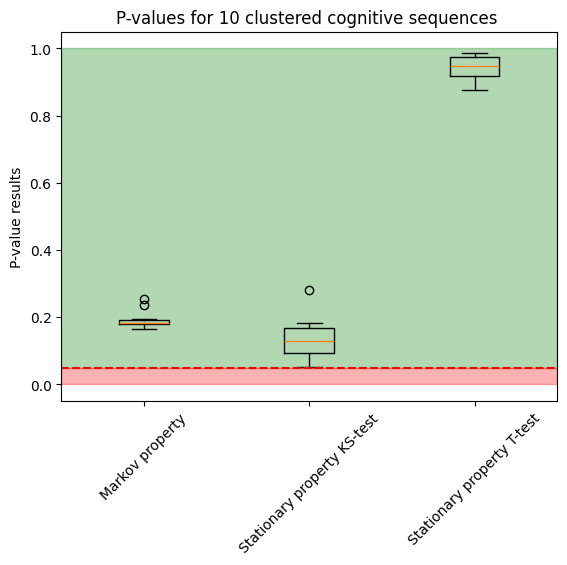

In [6]:
cognitive_states = cluster_neural_activity(N=x, 
                                           B=b.astype(int),
                                           n_clusters=3,
                                           nrep=10,
                                           ensemble=True,
                                           sim_m=200,
                                           sim_s='optimal',
                                           chunks=None,
                                           clustering='kmeans',
                                           kmeans_init='auto',
                                           test_mode='both',
                                           test_stationary_property=True,
                                           model=RandomForestClassifier(n_estimators=20, # we use a RandomForest
                                                                        random_state=42),
                                           plot=True)

The plot above shows the distributions of the p-values of the statistical tests for each of the simulated cognitive state sequences.


The method sorts the cognitive state sequence simulations according to the 'best' p-values.
Entries with p-values signaling no violations against the Markov property are listed first.

#### Each tuple in the list contains: 
- the sequence;
- p-value markov property;
- p-value stationary property ks-test (optional);
- p-value stationary property t-test (optional);

In [7]:
best_result = cognitive_states[0]
best_sequence = best_result[0]
best_result

(array([0, 0, 0, ..., 0, 0, 0], dtype=int32),
 0.255,
 0.1381274694237114,
 0.9346622587063885)

### Making Sense of the Output
The plot shows us the results of the tests, which see if there is sufficient evidence against one of the two properties. The p-value results for all repetitions of cognitive sequence clusterings are plotted, with values in the green signaling sequences that seem not to disrespect the properties according to the test. 

The result for the sequence with the most promising result (cognitive state sequence) is printed above. The Markov property (p-value = 0.255) and the stationary property (p-value = 0.138 or 0.935) do indicate that no evidence disrespecting both rules was found. The cognitive sequence could therefore be stemming from a Markov process 1st order.

## Plot the cognitive graph

Now after we have found a fitting cognitive state sequence, that seems not to violate any of the properties of a Markov Process, we can create a cognitive graph. First we plot the diagram with all edges by setting threshold to 0. Using the `weight_hist` parameter we see the distribution in edge thickness which can help us decide setting a threshold of minimal edge thickness for the cognitive graph.

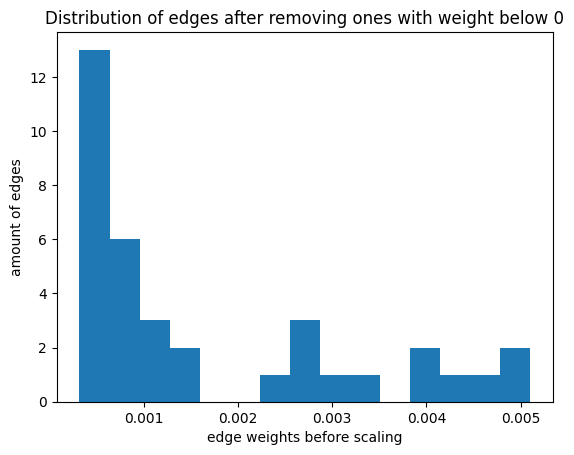

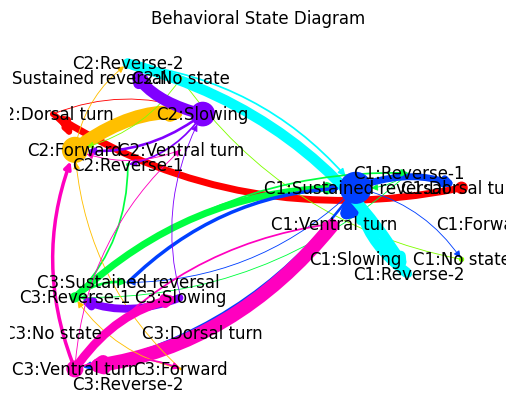

In [6]:
result = behavioral_state_diagram(best_sequence, b, behaviors=behaviors,
                                  weights_hist=True,
                                  bins=15,
                                  threshold=0)

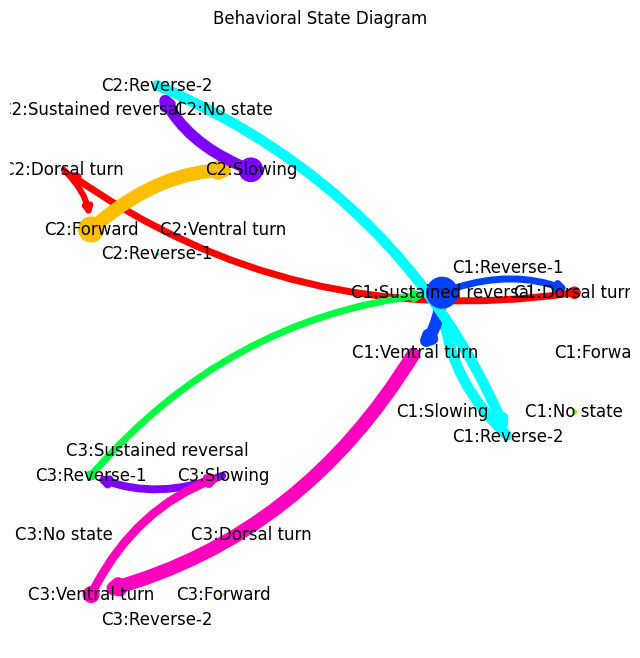

Calculated threshold is:  0.000510204081632653


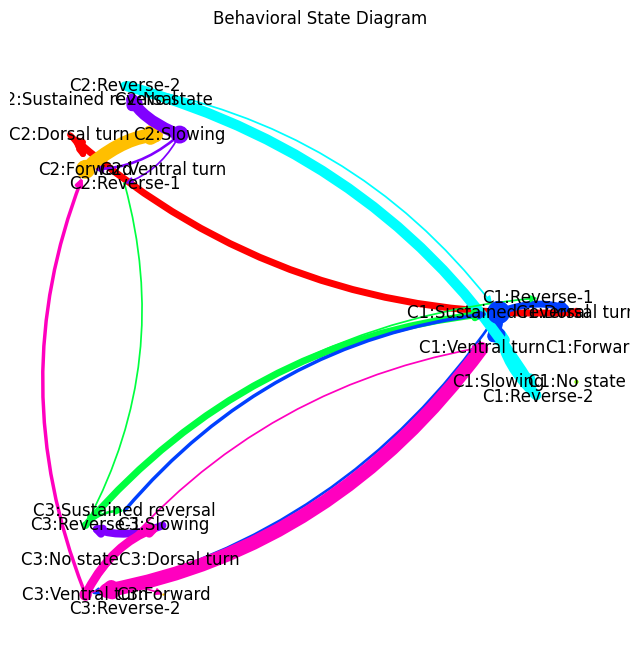

True

In [7]:

behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         threshold=0.002,
                         figsize=(8, 8))
behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         offset=5,
                         figsize=(8, 8))

Using these insights we can either let the algorithm decide where to put the cut-off or decide our self. We can also define an offset, this will change the spacing between clusters.

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']
Calculated threshold is:  0.000510204081632653


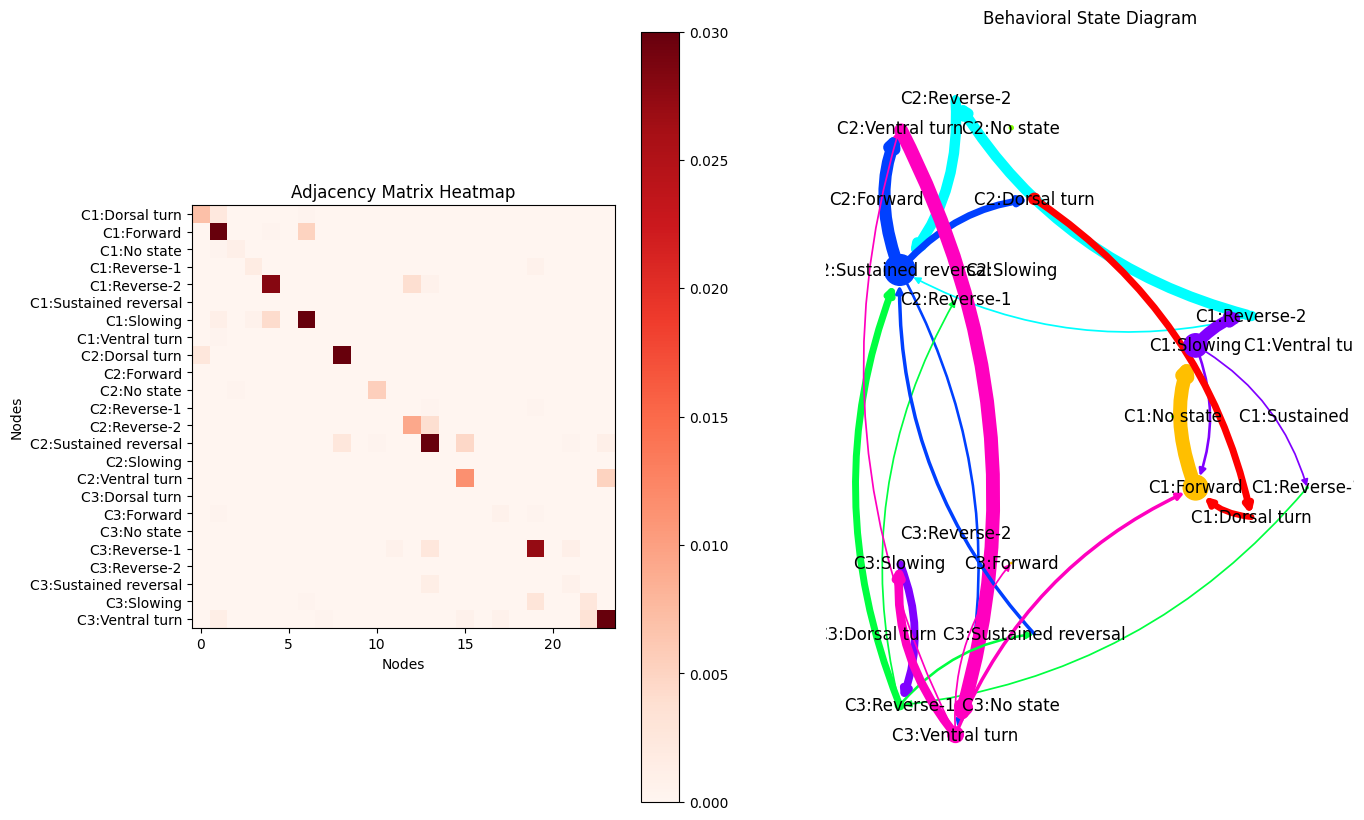

True

In [7]:
# Next we also plot the adjacency matrix
behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         adj_matrix=True,
                         figsize=(15, 10))

## Interactive plots (using pyvis)

For the interactive graph we set a filename were we want to save the HTML-file and we can also set an option parameter. This is set with a predefined physics script [options = 0, 1 or 2] or a custom script with a path to the JSON-file. The default value for options is 0, giving a graph with forces pushing nodes apart and pulling edges together. 

In [6]:
behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         interactive='figures/Interactive_graph',
                         options=0)

behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         interactive='figures/Interactive_graph_no_physics',
                         options='ncmcm/cognitive_graphs/json_physics/custom_physics.json')

Calculated threshold is:  0.000510204081632653
figures/Interactive_graph.html
Plot has been saved under: figures/Interactive_graph.html
Calculated threshold is:  0.000510204081632653
figures/Interactive_graph_no_physics.html
Plot has been saved under: figures/Interactive_graph_no_physics.html


True

# Interactive Plot 
- We used the Interactive_graph_no_physics.html file
- We display screenshots of the HTML-file, however accessing the files with a browser allows for a better user-experience

Below one can see three pictures of the interactive plots. In the first two images a node ("C2:Slowing" or "C2:Forward") has been selected using the select-menu at the top. This will only display nodes directly connected to it and their connections. The rest of the edges and nodes and there connections are greyed out.

In the third image we used the filter-menu directly below the select-menu to only show cognitive states 1 and 2. Using this we can display certain aspects of the plot in more detail.
<p>&nbsp;</p>
<img src="../figures/Interactive_selection.png" width="1600" alt="Interactive plot with a node selected.">
<img src="../figures/Interactive_selection_hover.png" width="1600" alt="Interactive plot with a node selected.">
<img src="../figures/Interactive_selection_C1_C2.png" width="1600" alt="Interactive plot with a certain clusters displayed.">



## Statistical tests

To demonstrate the effectiveness of the statistical tests, implemented and used to generate the best cognitive graphs according to the NCMCM-framework, we simulate 3 different sequences and test them.

In [12]:
# Simulate some sequences
seq_1, _ = simulate_markov_sequence(M=3000, N=5, order=1)
seq_2, _ = simulate_markov_sequence(M=3000, N=5, order=2)
seq_non_stat_3 = non_stationary_process(M=3000, N=5, changes=5)
seq_non_stat_4 = non_stationary_process2(M=3000, N=5,  changes=5, epsilon=0.05)


The `markov_property_test` returns the empirical 1st order transition matrix and a p-value.
A p-value below 0.05 signals behavior that seems to violate the memoryless property (aka. Markov property) of a 1st order Markov process.

In [13]:
p_1, P_1 = markov_property_test(seq_1, simulations=250)
p_2, P_2 = markov_property_test(seq_2, simulations=250)
print(f'Since {round(p_1, 3)} > 0.05, the sequence 1 could come from a 1st order Markov process.')
print(f'Since {round(p_2, 3)} < 0.05, the sequence 2 seems not to come from a 1st order Markov process.')

Since 0.24 > 0.05, the sequence 1 could come from a 1st order Markov process.
Since 0.0 < 0.05, the sequence 2 seems not to come from a 1st order Markov process.


The `stationary_property_test` returns the p-value for a KS- and/or T- test.
A p-value below 0.05 signals that the sequence violates the stationary property of a Markov process.

In [15]:

p_ks_test_1, _, p_t_test_1, _ = stationary_property_test(seq_1, 
                                                         chunks_num=5, 
                                                         simulations='optimal', 
                                                         test_mode='both')
p_ks_test_2, ks_statistic_2, p_t_test_2, t_statistic_2 = stationary_property_test(seq_non_stat_3, 
                                                                                  chunks_num=5, 
                                                                                  simulations='optimal',  
                                                                                  test_mode='both')
p_ks_test_3, ks_statistic_3, p_t_test_3, t_statistic_3 = stationary_property_test(seq_non_stat_4, 
                                                                                  chunks_num=5, 
                                                                                  simulations='optimal',  
                                                                                  test_mode='both')

print(f'Since {round(p_ks_test_1, 3)} > 0.05 and {round(p_t_test_1, 3)} > 0.05, the sequence 1 could come from a stationary Markov process')
print(f'Since {round(p_ks_test_2, 3)} < 0.05 and  {round(p_t_test_2, 3)} < 0.05, the sequence 3 seems not to come from a stationary Markov process')

print(f'Since {round(p_ks_test_3, 3)} < 0.05 and  {round(p_t_test_3, 3)} < 0.05, the sequence 4 seems not to come from a stationary Markov process')


Since 0.245 > 0.05 and 0.197 > 0.05, the sequence 1 could come from a stationary Markov process
Since 0.0 < 0.05 and  0.0 < 0.05, the sequence 3 seems not to come from a stationary Markov process
Since 0.0 < 0.05 and  0.005 < 0.05, the sequence 4 seems not to come from a stationary Markov process


It is important to note here, that the `stationary_property_test` gets very sensitive with big sample sizes. Which means long sequences in combination with many simulations can lead to significant results more easily. This is because the KS-test and the t-test, which are employed in this method, struggle with very different sample sizes, as large samples can overshadow smaller ones and make subtle differences appear statistically significant. Consequently, careful interpretation is needed, as results may not always reflect meaningful differences but rather the influence of sample size disparities. This can be somewhat mitigated by setting a lower value for `chunks_num`. It increases one sample size linearly while the second sample size increases exponentially, potentially skewing the comparison. 